# Tragedy of the Commons: Coupling Human Decisions to Lattice Ecology

**Methods:** Agent-based model (course-specified structure); Granovetter threshold vs. Q-learning decision rules on a spatial resource lattice; NumPy, Matplotlib

### Overview
This notebook develops an agent-based model (ABM) that adds human decision-making to an ecological dynamics model on a lattice.

---

### 1. Model Assumptions and the Program Flowchart

#### (a) Model Assumptions

##### Spatial Structure (Ecological Lattice)

- The environment is a 2D square lattice with size $L \times L$.
- Each lattice cell represents a local ecological patch.
- Each patch contains:
  - Plant biomass (resource) $R(x,y)$
  - Herbivore population (rabbit) $H(x,y)$
- The resource regenerates locally and is consumed by both herbivores and humans.
- Humans do not consume herbivores, even though humans are omnivores, to keep the model focused on the tragedy of the commons.

##### Agents Used for Ecological Dynamics

The model includes:

- Plant (resource) agents: continuous biomass on each lattice cell
- Herbivore (rabbit) agents: population density on each lattice cell

Carnivores are excluded to keep the trophic structure simple and focus on the interaction between humans, resources, and herbivores.

##### Human Agents (Decision Makers)

- Humans are located on lattice sites, with one human per cell.
- At each time step, each human chooses between:
  - **Cooperate (C)**: harvest the resource at a low level
  - **Defect (D):** harvest the resource at a high level

Human harvesting reduces the local plant biomass, which indirectly affects herbivore survival and reproduction.

##### Human Decision-Making Model

Two different human decision-making models are used:

- **Model 1: Norm-based model (Granovetter threshold model)**
Each human chooses cooperation when the fraction of cooperating neighbors exceeds their individual threshold.

- **Model 2: Learning-based model (Reinforcement learning / Q-learning)**
Each human updates the expected payoff of cooperation and defection based on ecological feedback and chooses an action using a softmax rule.

These two models represent different types of decision-making: social norms and learning from rewards.

The two models are implemented separately on the same ecological lattice model so their effects can be compared.

##### Coupling Between Ecology and Society
- Human actions reduce plant biomass.
- Plant biomass affects herbivore survival and reproduction.
- Ecological degradation reduces future human payoff and learning rewards.

This creates a feedback loop between human behavior and the ecological system:

*Human behavior -> resource level -> human payoff / social norms -> human behavior*

---

#### (b) Program Flowchart

1. Initialize the lattice

  - Resource $R(x,y)$
  - Herbivore population $H(x,y)$
  - Human strategy $S(x,y) \in {C,D}$
  - Human parameters such as thresholds and Q-values


2. Update the system at each time step

  - Ecological update
    - Plant growth and death
    - Herbivore consumption of plants
    - Herbivore reproduction, death, and movement

  - Human harvesting
    - Cooperators harvest plants at a low rate
    - Defectors harvest plants at a high rate

  - Human decision update
    - Granovetter: switch to cooperation when neighbor cooperation exceeds the threshold
    - Q-learning: update Q-values and action probabilities

  - Apply the feedback to the ecological system

3. Record global statistics
  - Plant density
  - Herbivore population
  - Fraction of cooperators

4. Repeat the simulation

---

### (c) Expected Behavior

- Model A (Granovetter):
  - Cooperation may spread through social norms and help maintain the resource level.

- Model B (Q-learning):
  - Short-term overexploitation may occur as agents learn, which may lead to oscillations or resource collapse.

The results of the two models are compared to examine how different human decision-making mechanisms affect the sustainability of the socio-ecological system.

---

Model structure/flowchart specified in course; implementation adapts my lattice-ecology code with class human-decision methods.

### Model A (Granovetter) and B (Q-learning)

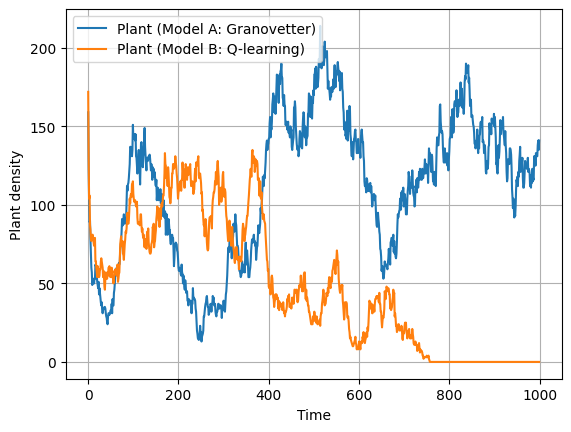

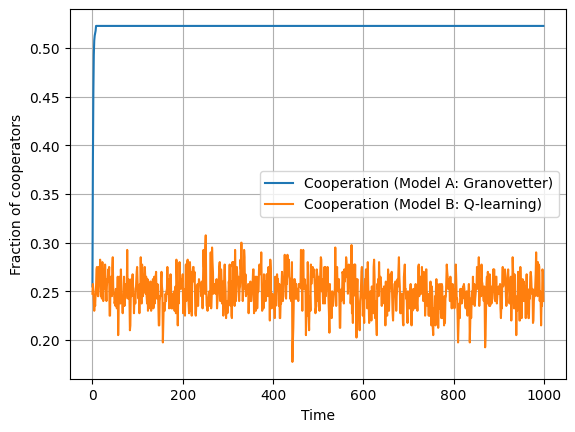

In [1]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt
import copy

#map parameters
size = 20
laststep = 1000

#plant parameters
growthprob = 0.4
deathprob = 0.05
Plantinitial = 0.4

#rabbit parameters
growthprobR = 0.4
deathprobR = 0.2
Rabitinitial = 0.3
moveprobR = 0.3

#human parameters
Humaninitial = 0.5
harvestC = 0.2
harvestD = 0.7

#Granovetter parameters
theta = 0.6
a = 1.0

#Q-learning parameters
alpha = 0.2
beta = 2.0

def bc(i):
  if i < 0:
    return i + size
  elif i >= size:
    return i - size
  else:
    return i

#Create map matrix
def init_world():
  habitat = [[0 for i in range(size)] for j in range(size)]
  habitatR = [[0 for i in range(size)] for j in range(size)]
  habitatH = [[0 for i in range(size)] for j in range(size)]
  strategyH = [[0 for i in range(size)] for j in range(size)]
  thresholdH = [[random.uniform(0, theta) for i in range(size)] for j in range(size)]
  Qcoop = [[0.0 for i in range(size)] for j in range(size)]
  Qdef = [[0.0 for i in range(size)] for j in range(size)]

  for i in range(size):
    for j in range(size):
      if random.random() < Plantinitial:
        habitat[i][j] = 1
      if random.random() < Rabitinitial:
        habitatR[i][j] = 2
      if random.random() < Humaninitial:
        habitatH[i][j] = 3
        strategyH[i][j] = 1 if random.random() < 0.5 else 0

  return habitat, habitatR, habitatH, strategyH, thresholdH, Qcoop, Qdef

#Ecology update
def ecological_update(ii, jj, habitat, habitatR):
  #Plant update
  if habitat[ii][jj] == 1 and habitatR[ii][jj] == 0:
    if random.random() > deathprob:
      if random.random() < growthprob:
        ic = random.randrange(-1, 2)
        jc = random.randrange(-1, 2)
        if ic*ic + jc*jc > 0:
          ni = bc(ii + ic)
          nj = bc(jj + jc)
          if habitat[ni][nj] == 0:
            habitat[ni][nj] = 1
    else:
      habitat[ii][jj] = 0

  #Rabbit update
  if habitatR[ii][jj] == 2:
    if random.random() > deathprobR:
      if habitat[ii][jj] == 1:
        habitat[ii][jj] = 0
      if random.random() < growthprobR:
        ic = random.randrange(-1, 2)
        jc = random.randrange(-1, 2)
        if ic*ic + jc*jc > 0:
          ni = bc(ii + ic)
          nj = bc(jj + jc)
          if habitatR[ni][nj] == 0:
            habitatR[ni][nj] = 2
      if random.random() < moveprobR:
        ic = random.randrange(-1, 2)
        jc = random.randrange(-1, 2)
        if ic*ic + jc*jc > 0:
          ni = bc(ii + ic)
          nj = bc(jj + jc)
          if habitatR[ni][nj] == 0:
            habitatR[ni][nj] = 2
            habitatR[ii][jj] = 0
    else:
      habitatR[ii][jj] = 0

#Human harvesting (shared for both model)
def human_harvest(ii, jj, habitat, habitatH, strategyH):
  reward = 0
  if habitatH[ii][jj] == 3 and habitat[ii][jj] == 1:
    if strategyH[ii][jj] == 1:
      if random.random() < harvestC:
        habitat[ii][jj] = 0
        reward = 1
    else:
      if random.random() < harvestD:
        habitat[ii][jj] = 0
        reward = 1
  return reward

#Model A: Granovetter update
def human_update_granovetter(ii, jj, habitatH, strategyH, thresholdH):
  if habitatH[ii][jj] == 3:
    coop_n = 0
    tot_n = 0
    for ic in [-1, 0, 1]:
      for jc in [-1, 0, 1]:
        if ic*ic + jc*jc > 0:
          ni = bc(ii + ic)
          nj = bc(jj + jc)
          if habitatH[ni][nj] == 3:
            tot_n += 1
            if strategyH[ni][nj] == 1:
              coop_n += 1
    if tot_n > 0:
      frac = coop_n / tot_n
      if strategyH[ii][jj] == 0 and thresholdH[ii][jj] <= a * frac:
        strategyH[ii][jj] = 1

#Model B: Q-learning update
def human_update_qlearning(ii, jj, habitat, habitatH, strategyH, Qcoop, Qdef):
  if habitatH[ii][jj] == 3:
    Qc = Qcoop[ii][jj]
    Qd = Qdef[ii][jj]
    Pcoop = math.exp(beta*Qc) / (math.exp(beta*Qc) + math.exp(beta*Qd))
    action = 1 if random.random() < Pcoop else 0

    reward = 1 if habitat[ii][jj] == 1 else -1

    if action == 1:
      Qcoop[ii][jj] += alpha * (reward - Qcoop[ii][jj])
    else:
      Qdef[ii][jj] += alpha * (reward - Qdef[ii][jj])

    strategyH[ii][jj] = action

#Run function
def run_model(model_type):
  habitatP, habitatR, habitatH, strategyH, thresholdH, Qc, Qd = init_world()

  initP = copy.deepcopy(habitatP)
  initR = copy.deepcopy(habitatR)
  initH = copy.deepcopy(habitatH)
  initS = copy.deepcopy(strategyH)


  Plantdensity = []
  Coopfrac = []

  for t in range(laststep):
    Ptotal = 0
    Ctotal = 0

    for i in range(size):
      for j in range(size):
        if habitatP[i][j] == 1:
          Ptotal += 1
        if habitatH[i][j] == 3 and strategyH[i][j] == 1:
          Ctotal += 1

    Plantdensity.append(Ptotal)
    Coopfrac.append(Ctotal / (size*size))

    for step in range(size*size):
      ii = random.randrange(size)
      jj = random.randrange(size)

      ecological_update(ii, jj, habitatP, habitatR)

      if model_type == "A":
        human_harvest(ii, jj, habitatP, habitatH, strategyH)
        human_update_granovetter(ii, jj, habitatH, strategyH, thresholdH)
      else:
        human_update_qlearning(ii, jj, habitatP, habitatH, strategyH, Qc, Qd)
        human_harvest(ii, jj, habitatP, habitatH, strategyH)

  return initP, habitatP, initR, habitatR, initH, habitatH, initS, strategyH, Plantdensity, Coopfrac

#run model
initP_A, finalP_A, initR_A, finalR_A, initH_A, finalH_A, initS_A, finalS_A, Plant_A_ts, Coop_A_ts = run_model("A")
initP_B, finalP_B, initR_B, finalR_B, initH_B, finalH_B, initS_B, finalS_B, Plant_B_ts, Coop_B_ts = run_model("B")



t = np.arange(laststep)

plt.figure()
plt.plot(t, Plant_A_ts, label="Plant (Model A: Granovetter)")
plt.plot(t, Plant_B_ts, label="Plant (Model B: Q-learning)")
plt.xlabel("Time")
plt.ylabel("Plant density")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(t, Coop_A_ts, label="Cooperation (Model A: Granovetter)")
plt.plot(t, Coop_B_ts, label="Cooperation (Model B: Q-learning)")
plt.xlabel("Time")
plt.ylabel("Fraction of cooperators")
plt.legend()
plt.grid(True)
plt.show()


Map for model A (Granovetter)

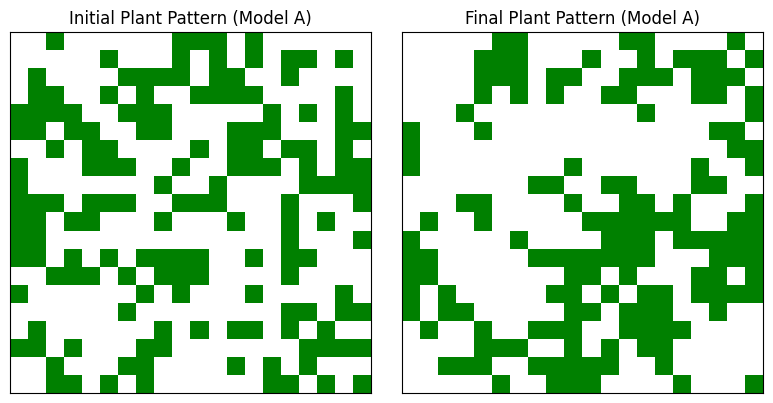

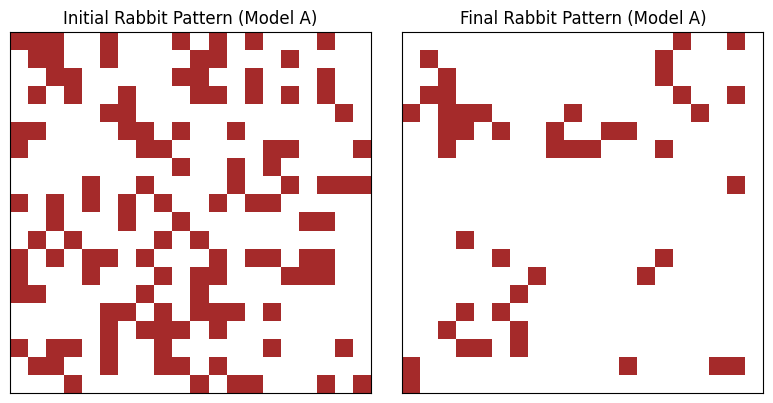

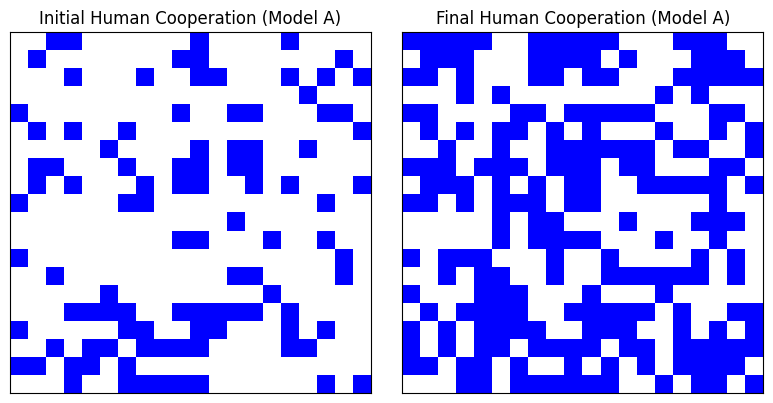

In [2]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

#plant
cmapP = ListedColormap(['white', 'green'])

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].matshow(initP_A, cmap=cmapP)
axes[0].set_title('Initial Plant Pattern (Model A)')
axes[0].set_xticks([])
axes[0].set_yticks([])

axes[1].matshow(finalP_A, cmap=cmapP)
axes[1].set_title('Final Plant Pattern (Model A)')
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

#Rabbit
cmapR = ListedColormap(['white', 'brown'])

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].matshow(initR_A, cmap=cmapR)
axes[0].set_title('Initial Rabbit Pattern (Model A)')
axes[0].set_xticks([])
axes[0].set_yticks([])

axes[1].matshow(finalR_A, cmap=cmapR)
axes[1].set_title('Final Rabbit Pattern (Model A)')
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

#Human
cmapH = ListedColormap(['white', 'blue'])

initCoopMap_A = [[1 if initS_A[i][j] == 1 else 0 for j in range(size)] for i in range(size)]
finalCoopMap_A = [[1 if finalS_A[i][j] == 1 else 0 for j in range(size)] for i in range(size)]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].matshow(initCoopMap_A, cmap=cmapH)
axes[0].set_title('Initial Human Cooperation (Model A)')
axes[0].set_xticks([])
axes[0].set_yticks([])

axes[1].matshow(finalCoopMap_A, cmap=cmapH)
axes[1].set_title('Final Human Cooperation (Model A)')
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.tight_layout()
plt.show()


Map for model B (Q-learning)

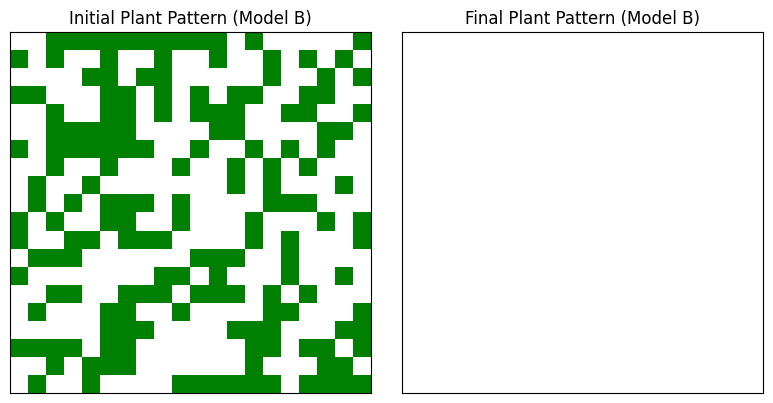

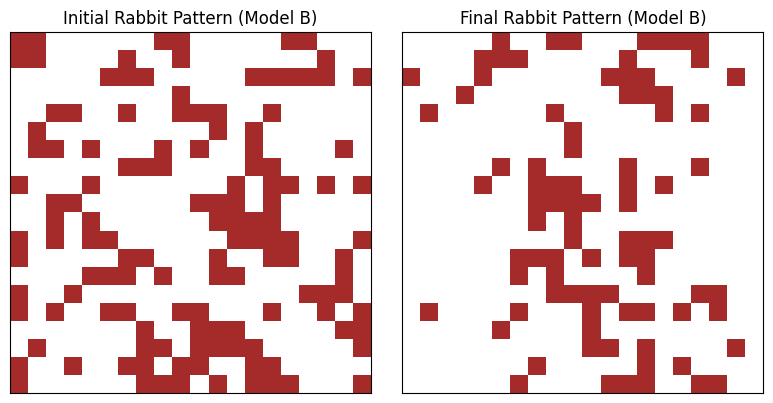

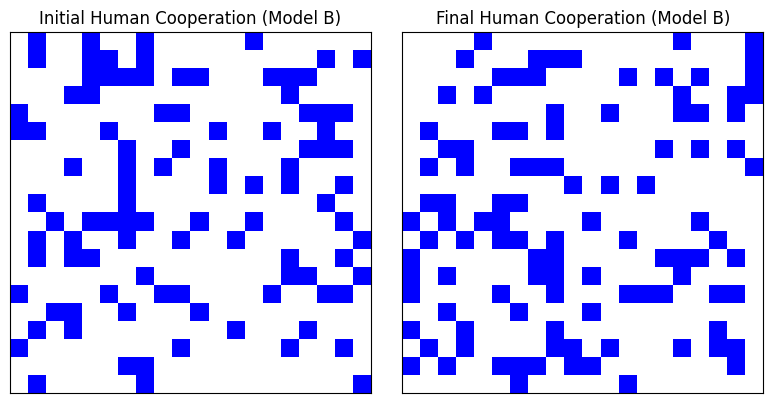

In [3]:
# Plant
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].matshow(initP_B, cmap=cmapP)
axes[0].set_title('Initial Plant Pattern (Model B)')
axes[0].set_xticks([])
axes[0].set_yticks([])

axes[1].matshow(finalP_B, cmap=cmapP)
axes[1].set_title('Final Plant Pattern (Model B)')
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

# Rabbit
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].matshow(initR_B, cmap=cmapR)
axes[0].set_title('Initial Rabbit Pattern (Model B)')
axes[0].set_xticks([])
axes[0].set_yticks([])

axes[1].matshow(finalR_B, cmap=cmapR)
axes[1].set_title('Final Rabbit Pattern (Model B)')
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.tight_layout()
plt.show()


# Human
initCoopMap_B = [[1 if initS_B[i][j] == 1 else 0 for j in range(size)] for i in range(size)]
finalCoopMap_B = [[1 if finalS_B[i][j] == 1 else 0 for j in range(size)] for i in range(size)]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].matshow(initCoopMap_B, cmap=cmapH)
axes[0].set_title('Initial Human Cooperation (Model B)')
axes[0].set_xticks([])
axes[0].set_yticks([])

axes[1].matshow(finalCoopMap_B, cmap=cmapH)
axes[1].set_title('Final Human Cooperation (Model B)')
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.tight_layout()
plt.show()


---

### Discussion

The simulation shows that human decision-making significantly affects the ecological system.

In the Granovetter model (Model A), cooperation can gradually increase because humans copy cooperative behavior from their neighbors when many nearby people cooperate. As cooperation spreads, plants are harvested more carefully, so plant density tends to remain higher and more stable.

In contrast, in the Q-learning model (Model B), humans learn mainly from their own short-term rewards. This often leads to more selfish harvesting when plants are available, which can reduce plant density faster and make cooperation harder to maintain. As a result, the ecological system under Model B is more likely to experience resource decline or unstable fluctuations.

Overall, the results show that social imitation supports sustainable resource use better than purely individual trial-and-error learning in this model.
